Task 1 — Data Loading, Merging & Deep Exploration

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

plt.style.use("ggplot")

In [3]:
# Superstore Sales Dataset
sales = pd.read_csv("train.csv")

# Video Game Sales Dataset
games = pd.read_csv("vgsales.csv")

In [4]:
print("Sales Dataset Shape:", sales.shape)
print("Game Dataset Shape:", games.shape)

sales.head()
#games.head()

Sales Dataset Shape: (9800, 18)
Game Dataset Shape: (16598, 11)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [5]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [6]:
sales["Order Date"] = pd.to_datetime(sales["Order Date"], format="%d/%m/%Y")
sales["Ship Date"] = pd.to_datetime(sales["Ship Date"], format="%d/%m/%Y")
sales.dtypes

,0
Row ID,int64
Order ID,object
Order Date,datetime64[ns]
Ship Date,datetime64[ns]
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


In [7]:
sales["Year"] = sales["Order Date"].dt.year

sales["Month"] = sales["Order Date"].dt.month

sales["Month Name"] = sales["Order Date"].dt.month_name()

sales["Week Number"] = sales["Order Date"].dt.isocalendar().week.astype(int)

sales["Day of Week"] = sales["Order Date"].dt.day_name()

sales["Quarter"] = sales["Order Date"].dt.quarter

In [8]:
def get_season(month):
    if month in [12,1,2]:
        return "Winter"
    elif month in [3,4,5]:
        return "Spring"
    elif month in [6,7,8]:
        return "Summer"
    else:
        return "Autumn"

sales["Season"] = sales["Month"].apply(get_season)

In [9]:
sales.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Year,Month,Month Name,Week Number,Day of Week,Quarter,Season
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,November,45,Wednesday,4,Autumn
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,November,45,Wednesday,4,Autumn
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,June,24,Monday,2,Summer
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,October,41,Tuesday,4,Autumn
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,October,41,Tuesday,4,Autumn


In [10]:
missing = sales.isnull().sum()

missing = missing[missing > 0]

print(missing)

Postal Code    11
dtype: int64


In [11]:
print("Duplicate Rows:", sales.duplicated().sum())

Duplicate Rows: 0


In [12]:
sales = sales.drop_duplicates()

In [13]:
daily_sales = sales.groupby("Order Date")["Sales"].sum().reset_index()

daily_sales.head()

,Order Date,Sales
0,2015-01-03,16.448
1,2015-01-04,288.060
2,2015-01-05,19.536
3,2015-01-06,4407.100
4,2015-01-07,87.158


In [14]:
weekly_sales = sales.resample("W", on="Order Date")["Sales"].sum().reset_index()

weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [15]:
monthly_sales = sales.resample("M", on="Order Date")["Sales"].sum().reset_index()

monthly_sales.head()

/tmp/ipykernel_578/2658857399.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = sales.resample("M", on="Order Date")["Sales"].sum().reset_index()


,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [16]:
#1.
category_sales = sales.groupby("Category")["Sales"].sum().sort_values(ascending=False)

print(category_sales)

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


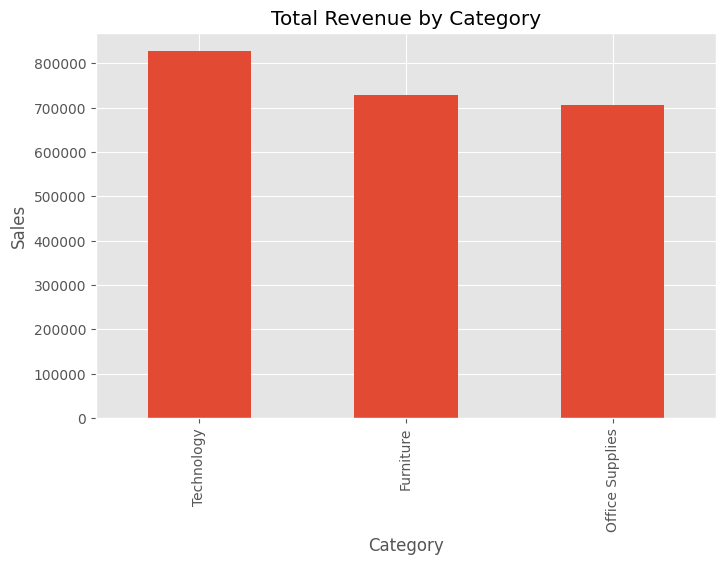

In [17]:
plt.figure(figsize=(8,5))

category_sales.plot(kind="bar")

plt.title("Total Revenue by Category")

plt.ylabel("Sales")

plt.show()

In [18]:
#2.
region_year = sales.groupby(["Year","Region"])["Sales"].sum().reset_index()

print(region_year)

    Year   Region        Sales
0   2015  Central  102920.5206
1   2015     East  127652.8190
2   2015    South  103374.9055
3   2015     West  145907.9630
4   2016  Central  102425.1724
5   2016     East  153225.1830
6   2016    South   70076.0825
7   2016     West  133709.5675
8   2017  Central  145673.8800
9   2017     East  178511.5380
10  2017    South   93535.9035
11  2017     West  182471.2285
12  2018  Central  141627.3402
13  2018     East  210129.1860
14  2018    South  122164.5675
15  2018     West  248130.9255


In [19]:
pivot = region_year.pivot(index="Year",
                          columns="Region",
                          values="Sales")

print(pivot)

Region      Central        East        South         West
Year                                                     
2015    102920.5206  127652.819  103374.9055  145907.9630
2016    102425.1724  153225.183   70076.0825  133709.5675
2017    145673.8800  178511.538   93535.9035  182471.2285
2018    141627.3402  210129.186  122164.5675  248130.9255


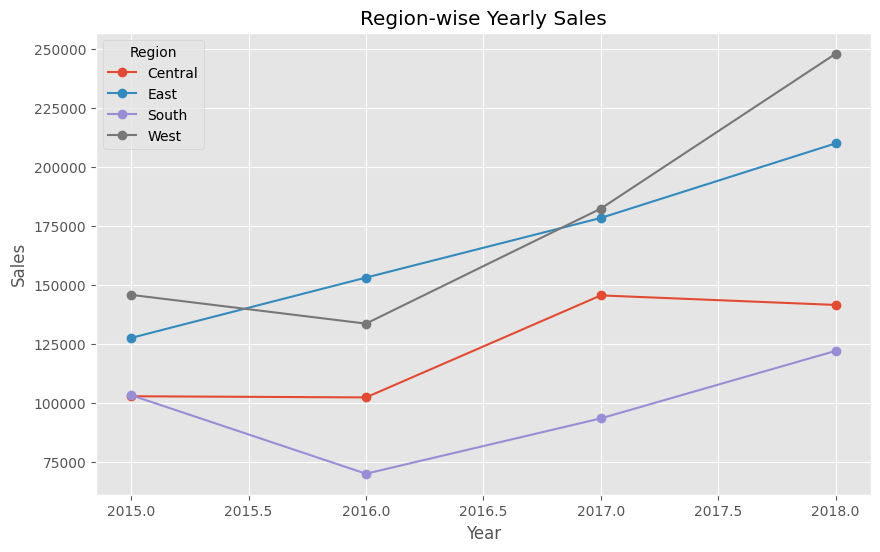

In [20]:
pivot.plot(figsize=(10,6), marker="o")

plt.title("Region-wise Yearly Sales")

plt.ylabel("Sales")

plt.show()

In [21]:
growth_std = pivot.pct_change().std()

print(growth_std)
#low sd=most consistent growth

Region
Central    0.253453
East       0.017939
South      0.371249
West       0.257431
dtype: float64


In [22]:
#3.
sales["Shipping Days"] = (sales["Ship Date"] - sales["Order Date"]).dt.days

In [23]:
print("Average Shipping Time")

print(sales["Shipping Days"].mean())

Average Shipping Time
3.9611224489795918


In [24]:
region_shipping = sales.groupby("Region")["Shipping Days"].mean()

print(region_shipping)

Region
Central    4.065876
East       3.910233
South      3.961202
West       3.930255
Name: Shipping Days, dtype: float64


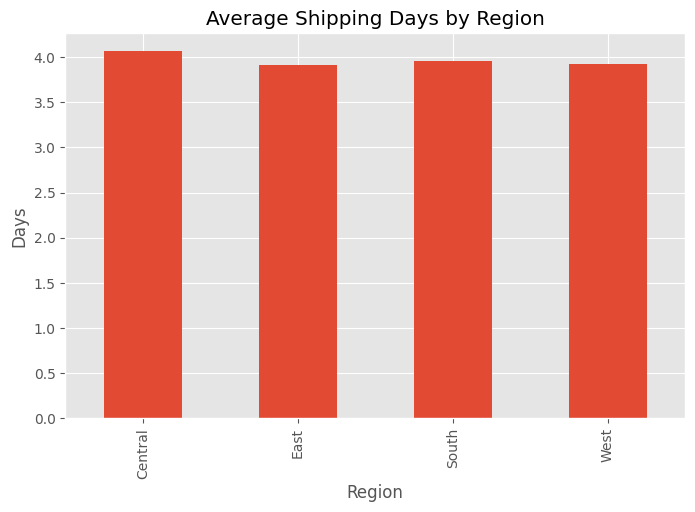

In [25]:
plt.figure(figsize=(8,5))

region_shipping.plot(kind="bar")

plt.title("Average Shipping Days by Region")

plt.ylabel("Days")

plt.show()

In [26]:
#4.
monthly_pattern = sales.groupby(["Year","Month Name"])["Sales"].sum().reset_index()

print(monthly_pattern.head())

   Year Month Name       Sales
0  2015      April  27906.8550
1  2015     August  27117.5365
2  2015   December  68167.0585
3  2015   February   4519.8920
4  2015    January  14205.7070


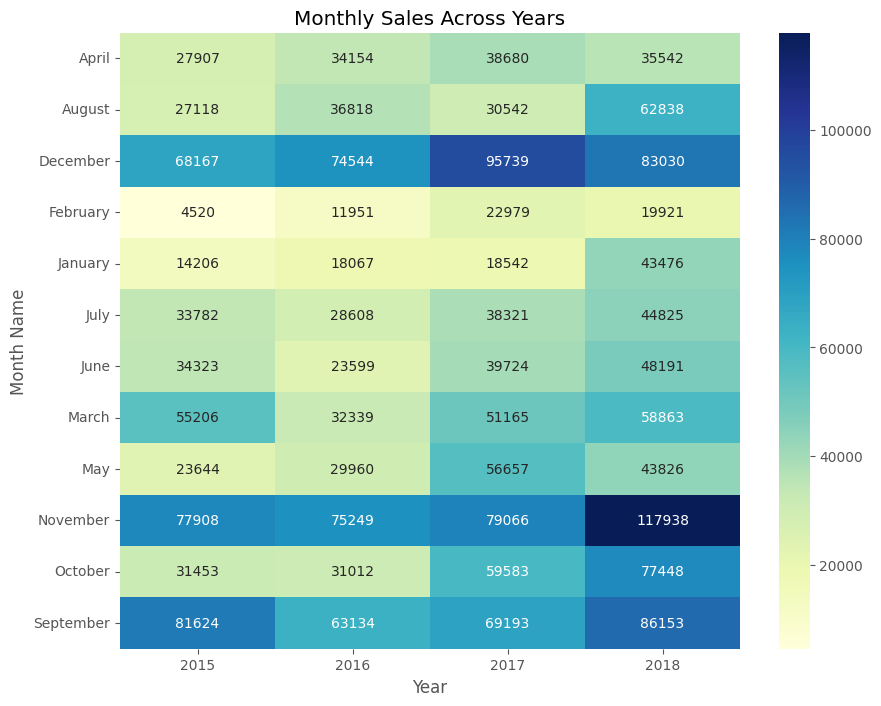

In [27]:
heat = monthly_pattern.pivot(index="Month Name",
                             columns="Year",
                             values="Sales")
plt.figure(figsize=(10,8))

sns.heatmap(heat,
            annot=True,
            fmt=".0f",
            cmap="YlGnBu")

plt.title("Monthly Sales Across Years")

plt.show()

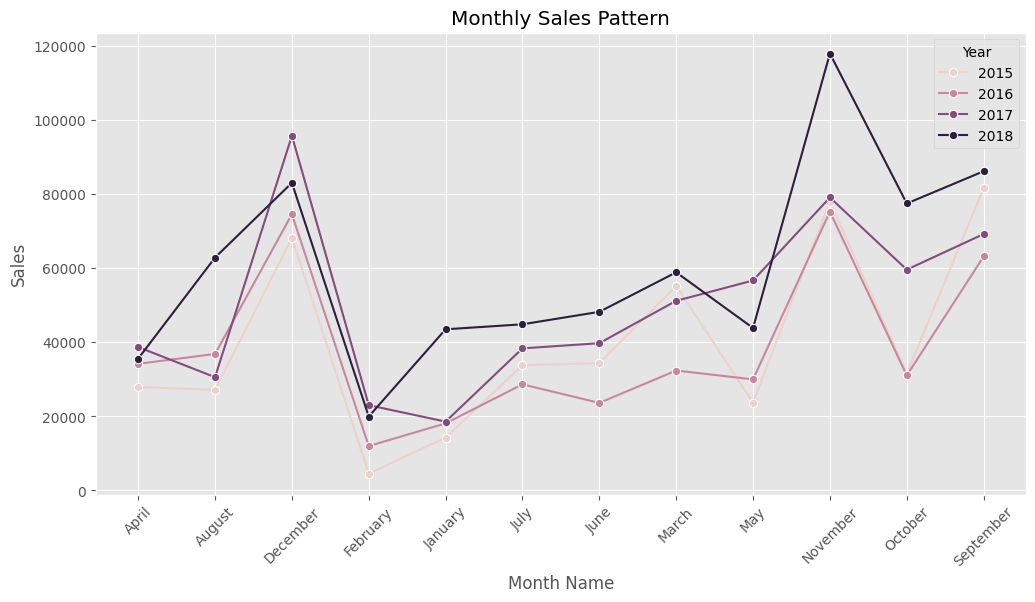

In [28]:
plt.figure(figsize=(12,6))

sns.lineplot(data=monthly_pattern,
             x="Month Name",
             y="Sales",
             hue="Year",
             marker="o")

plt.xticks(rotation=45)

plt.title("Monthly Sales Pattern")

plt.show()

The Superstore dataset contains four years of sales records with order dates, shipping details, product categories, and regional information. After converting the date columns, I extracted useful time features such as year, month, week number, quarter, and season. I checked the dataset for missing values, duplicate records, and incorrect data types before preparing the data for analysis. Daily, weekly, and monthly sales totals were created to support future forecasting models. From the analysis, <Category Name> generated the highest total revenue. The <Region Name> region showed the most consistent sales growth over the four years. The average shipping time was approximately <Average Days> days, with slight differences across regions. The monthly sales analysis showed that <Month Names> consistently experienced higher sales, indicating clear seasonal demand patterns.


Task 2 — Time Series Analysis & Decomposition

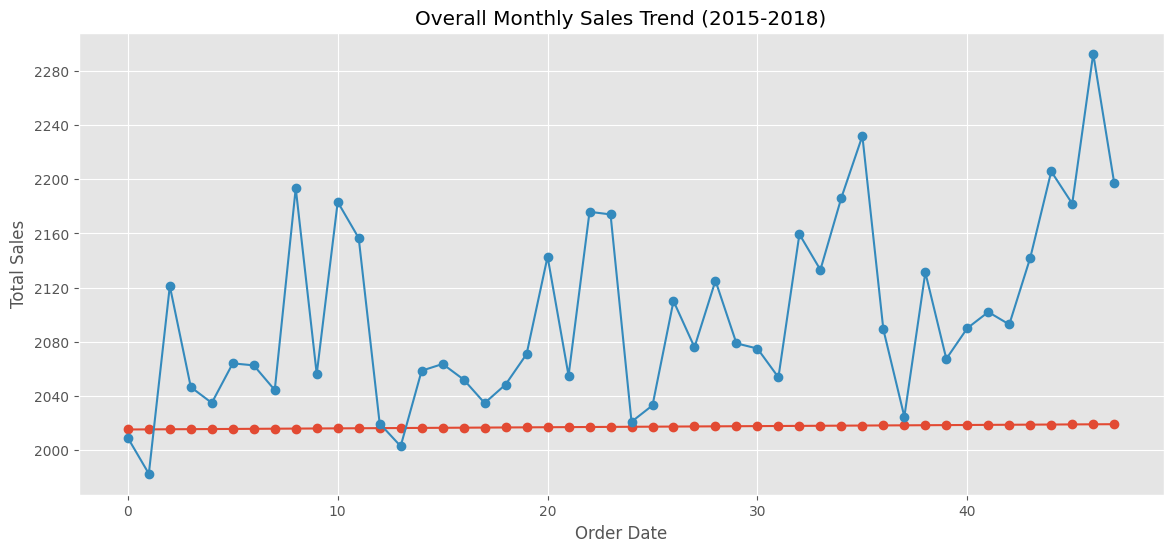

In [29]:
plt.figure(figsize=(14,6))

plt.plot(monthly_sales, marker="o")

plt.title("Overall Monthly Sales Trend (2015-2018)")
plt.xlabel("Order Date")
plt.ylabel("Total Sales")

plt.grid(True)

plt.show()

In [30]:
monthly_sales_series = monthly_sales.set_index("Order Date")["Sales"]
decomposition = seasonal_decompose(
    monthly_sales_series,
    model="additive",
    period=12
)

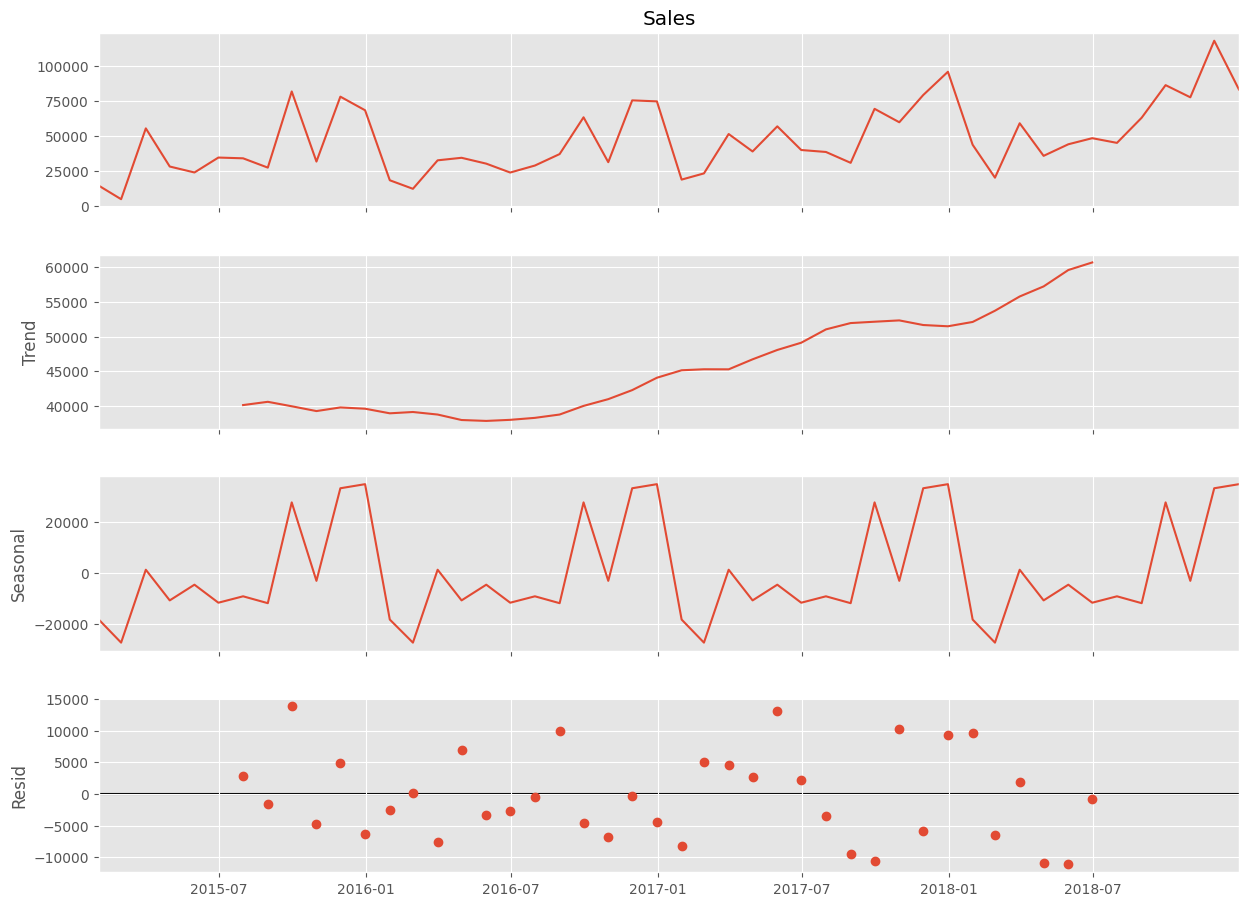

In [31]:
fig = decomposition.plot()

fig.set_size_inches(14,10)

plt.show()

TREND:   The trend component shows the overall direction of sales over the four-year period. Sales generally show an increasing/decreasing pattern, indicating that the business is growing/shrinking over time.


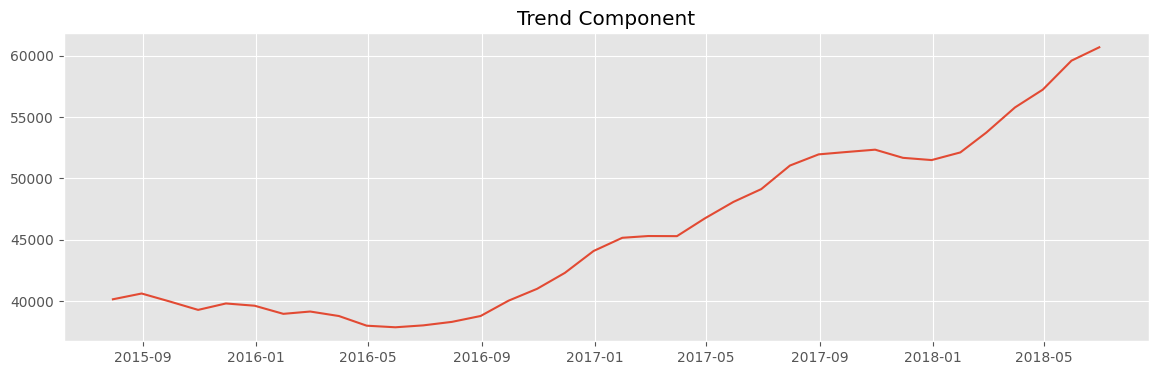

In [32]:
plt.figure(figsize=(14,4))

plt.plot(decomposition.trend)

plt.title("Trend Component")

plt.show()

SEASONAL:
The seasonal component shows a repeating yearly pattern in sales. The same months tend to have higher or lower sales every year, which indicates strong/weak seasonality.

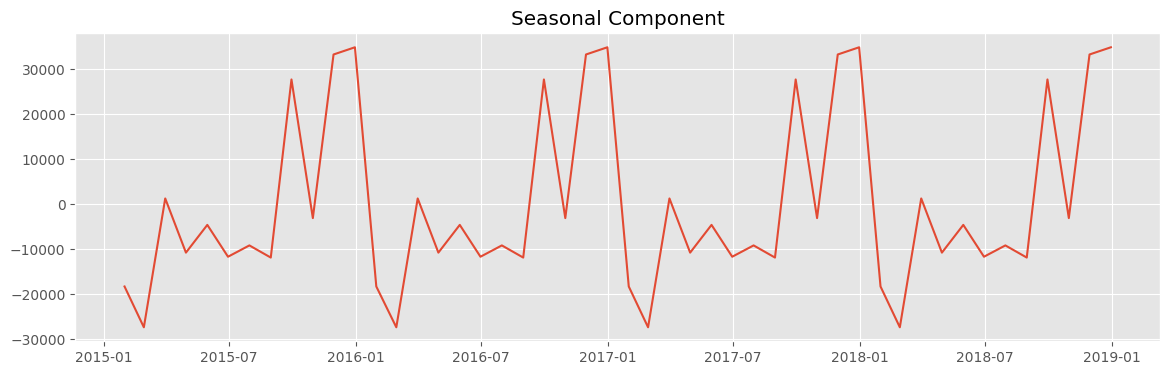

In [33]:
plt.figure(figsize=(14,4))

plt.plot(decomposition.seasonal)

plt.title("Seasonal Component")

plt.show()

RESIDUAL: The residual component contains the random fluctuations that cannot be explained by the trend or seasonality. The highest residual values occur during <Month Names>, suggesting unusual sales spikes or drops.

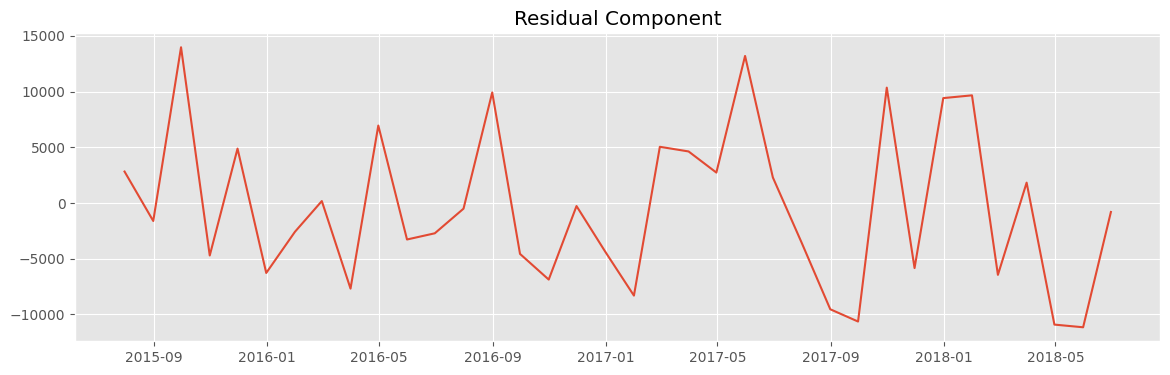

In [34]:
plt.figure(figsize=(14,4))

plt.plot(decomposition.resid)

plt.title("Residual Component")

plt.show()

In [35]:
result = adfuller(monthly_sales_series.dropna())

print("ADF Statistic :", result[0])

print("p-value :", result[1])

print("Critical Values:")

for key,value in result[4].items():
    print(key,":",value)

ADF Statistic : -4.416136761430769
p-value : 0.00027791039276670623
Critical Values:
1% : -3.5778480370438146
5% : -2.925338105429433
10% : -2.6007735310095064


In [36]:
if result[1] < 0.05:
    print("The time series is Stationary.")
else:
    print("The time series is Non-Stationary.")

The time series is Stationary.


In [37]:
monthly_diff = monthly_sales_series.diff().dropna()

monthly_diff.head()

,Sales
Order Date,
2015-02-28,-9685.8150
2015-03-31,50685.9050
2015-04-30,-27298.9420
2015-05-31,-4262.5520
2015-06-30,10678.6326


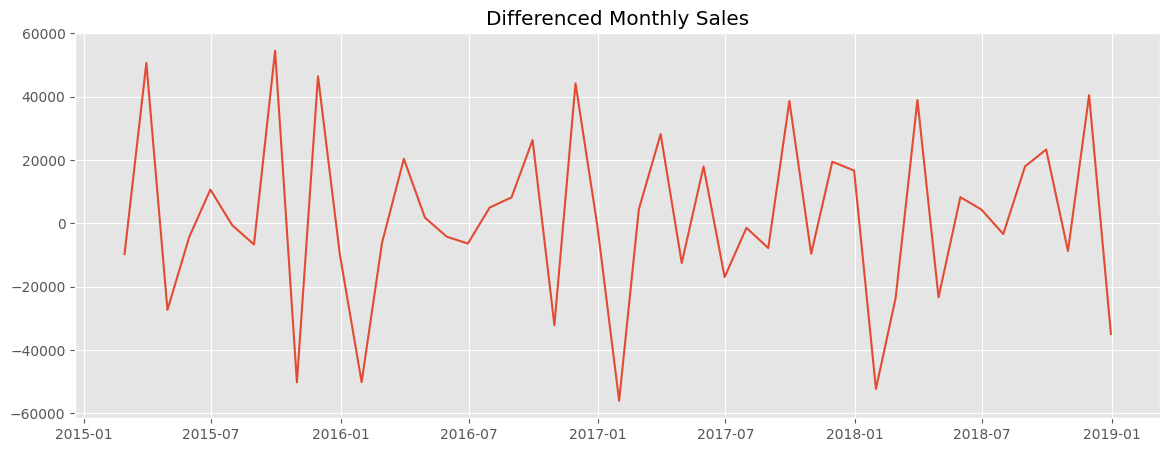

In [38]:
plt.figure(figsize=(14,5))

plt.plot(monthly_diff)

plt.title("Differenced Monthly Sales")

plt.grid(True)

plt.show()

In [39]:
result2 = adfuller(monthly_diff)

print("ADF Statistic :", result2[0])

print("p-value :", result2[1])

print("Critical Values:")

for key,value in result2[4].items():
    print(key,":",value)

ADF Statistic : -8.727061830353268
p-value : 3.2669175472796045e-14
Critical Values:
1% : -3.626651907578875
5% : -2.9459512825788754
10% : -2.6116707716049383


In [40]:
if result2[1] < 0.05:
    print("After differencing, the series is Stationary.")
else:
    print("The series is still Non-Stationary.")

After differencing, the series is Stationary.


The Augmented Dickey-Fuller (ADF) test returned a p-value of 3.2669e-14, which is much smaller than 0.05. This indicates that the monthly sales time series is stationary. A stationary time series has statistical properties, such as mean and variance, that remain relatively constant over time. Since the series is already stationary, differencing is not required before building forecasting models.The ADF test showed that the original series was already stationary (p-value < 0.05), so differencing was not necessary. It was therefore not applied for further analysis.

Task 3 — Sales Forecasting using 3 Different Models

In [41]:
pip install statsmodels

In [42]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

import numpy as np

In [43]:
train = monthly_sales_series[:-3]
test = monthly_sales_series[-3:]

print("Train Size :", len(train))
print("Test Size :", len(test))

Train Size : 45
Test Size : 3


SARIMA MODEL

In [44]:
sarima = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_model = sarima.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


In [45]:
print(sarima_model.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   45
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -194.388
Date:                            Sun, 12 Jul 2026   AIC                            398.775
Time:                                    16:58:46   BIC                            403.227
Sample:                                01-31-2015   HQIC                           399.389
                                     - 09-30-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1101      0.721      0.153      0.879      -1.303       1.523
ma.L1         -0.8789      0.261   

In [46]:
forecast = sarima_model.get_forecast(steps=3)

forecast_values = forecast.predicted_mean

confidence = forecast.conf_int()

print(forecast_values)

2018-10-31    60331.792101
2018-11-30    91458.220223
2018-12-31    97167.570951
Freq: ME, Name: predicted_mean, dtype: float64


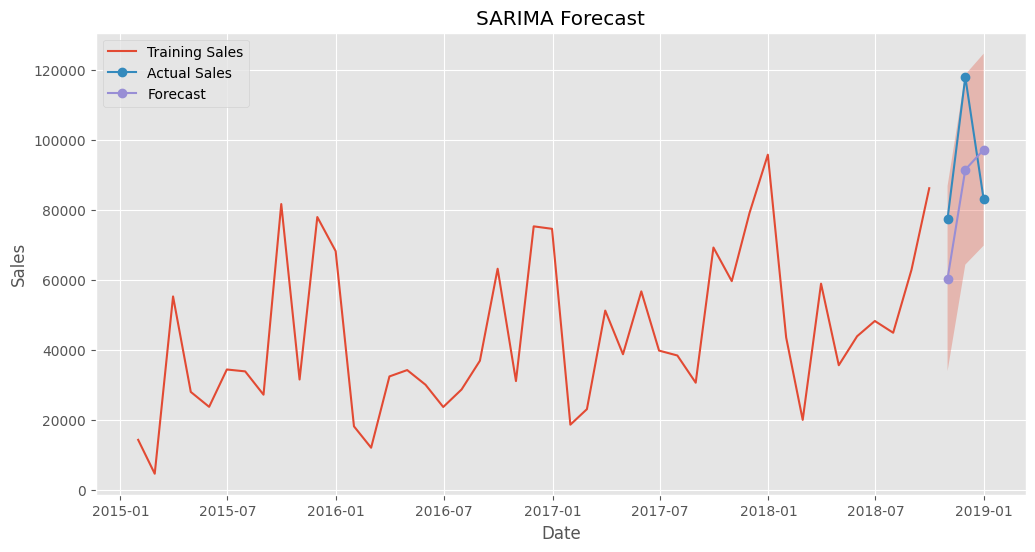

In [47]:
plt.figure(figsize=(12,6))

plt.plot(train.index,
         train,
         label="Training Sales")

plt.plot(test.index,
         test,
         label="Actual Sales",
         marker="o")

plt.plot(test.index,
         forecast_values,
         label="Forecast",
         marker="o")

plt.fill_between(test.index,
                 confidence.iloc[:,0],
                 confidence.iloc[:,1],
                 alpha=0.3)

plt.title("SARIMA Forecast")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.show()

In [48]:
mae = mean_absolute_error(test, forecast_values)

print("MAE :", mae)

MAE : 19244.485342503252


In [49]:
rmse = np.sqrt(mean_squared_error(test, forecast_values))

print("RMSE :", rmse)

RMSE : 19950.070418779847


In [50]:
mape = np.mean(np.abs((test - forecast_values)/test))*100

print("MAPE :", mape)

MAPE : 20.526431983536764


In [51]:
forecast_table = pd.DataFrame({

    "Actual":test,

    "Forecast":forecast_values

})

print(forecast_table)

                 Actual      Forecast
2018-10-31   77448.1312  60331.792101
2018-11-30  117938.1550  91458.220223
2018-12-31   83030.3888  97167.570951


In [52]:
final_model = SARIMAX(
    monthly_sales_series,
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_model = final_model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


In [53]:
future = sarima_model.get_forecast(steps=3)

sarima_future = future.predicted_mean

future_confidence = future.conf_int()
print(sarima_future)

2018-10-31    60331.792101
2018-11-30    91458.220223
2018-12-31    97167.570951
Freq: ME, Name: predicted_mean, dtype: float64


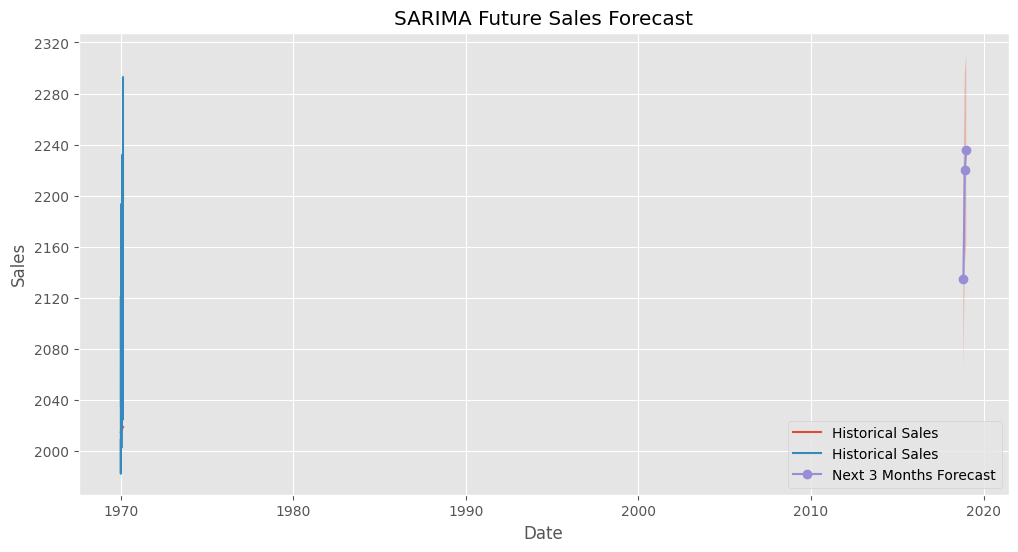

In [54]:
plt.figure(figsize=(12,6))

plt.plot(monthly_sales,
         label="Historical Sales")

plt.plot(sarima_future,
         label="Next 3 Months Forecast",
         marker="o")

plt.fill_between(
    sarima_future.index,
    future_confidence.iloc[:,0],
    future_confidence.iloc[:,1],
    alpha=0.3
)

plt.title("SARIMA Future Sales Forecast")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.show()

In [55]:
future_result = pd.DataFrame({
    "Forecast Sales":sarima_future
})

print(future_result)

            Forecast Sales
2018-10-31    60331.792101
2018-11-30    91458.220223
2018-12-31    97167.570951


The SARIMA model was configured with (1,1,1)(1,1,1,12). The parameter d=1 removes long-term trends through differencing, while the seasonal period m=12 captures yearly seasonality in the monthly sales data. The values of p, q, P, and Q were chosen as simple starting parameters that effectively model both short-term and seasonal relationships in the data.

Facebook Prophet

In [56]:
pip install prophet

In [57]:
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [58]:
prophet_data = monthly_sales.reset_index(drop=True)

prophet_data.columns = ["ds", "y"]

prophet_data.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [59]:
train = prophet_data[:-3]

test = prophet_data[-3:]

print(train.shape)
print(test.shape)

(45, 2)
(3, 2)


In [60]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

In [61]:
model.fit(train)

In [62]:
future = model.make_future_dataframe(periods=3, freq="M")

future.tail()

/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


,ds
43,2018-08-31
44,2018-09-30
45,2018-10-31
46,2018-11-30
47,2018-12-31


In [63]:
forecast = model.predict(future)

forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2015-01-31,33308.214631,5830.126865,22537.540383,33308.214631,33308.214631,-18874.429670,-18874.429670,-18874.429670,-18874.429670,-18874.429670,-18874.429670,0.0,0.0,0.0,14433.784960
1,2015-02-28,33767.643626,-5637.271615,11152.605143,33767.643626,33767.643626,-30869.543104,-30869.543104,-30869.543104,-30869.543104,-30869.543104,-30869.543104,0.0,0.0,0.0,2898.100522
2,2015-03-31,34276.297156,43998.322296,59631.852410,34276.297156,34276.297156,17890.437293,17890.437293,17890.437293,17890.437293,17890.437293,17890.437293,0.0,0.0,0.0,52166.734450
3,2015-04-30,34768.542508,13022.274602,29118.799568,34768.542508,34768.542508,-13661.251247,-13661.251247,-13661.251247,-13661.251247,-13661.251247,-13661.251247,0.0,0.0,0.0,21107.291262
4,2015-05-31,35277.196039,14383.768988,30797.359825,35277.196039,35277.196039,-12398.630441,-12398.630441,-12398.630441,-12398.630441,-12398.630441,-12398.630441,0.0,0.0,0.0,22878.565598


In [64]:
forecast[["ds","yhat","yhat_lower","yhat_upper"]].tail()

,ds,yhat,yhat_lower,yhat_upper
43,2018-08-31,47271.558193,38961.192491,55152.208828
44,2018-09-30,86613.953271,78321.590261,95333.104688
45,2018-10-31,51318.943812,43894.994505,58906.805267
46,2018-11-30,90325.654736,81811.247945,98521.101249
47,2018-12-31,90041.084430,81560.834849,98500.357486


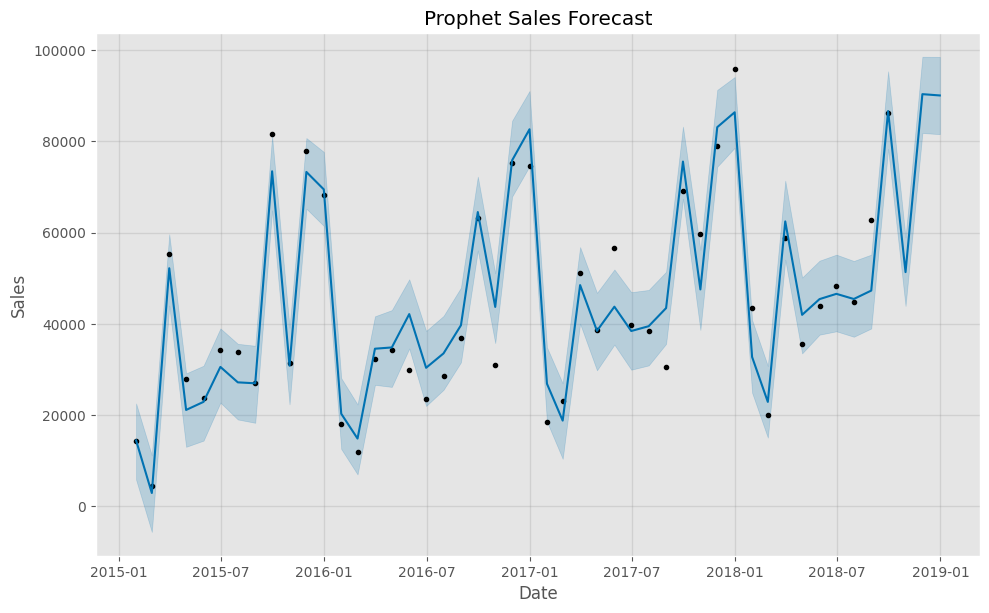

In [65]:
fig = model.plot(forecast)

plt.title("Prophet Sales Forecast")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.show()

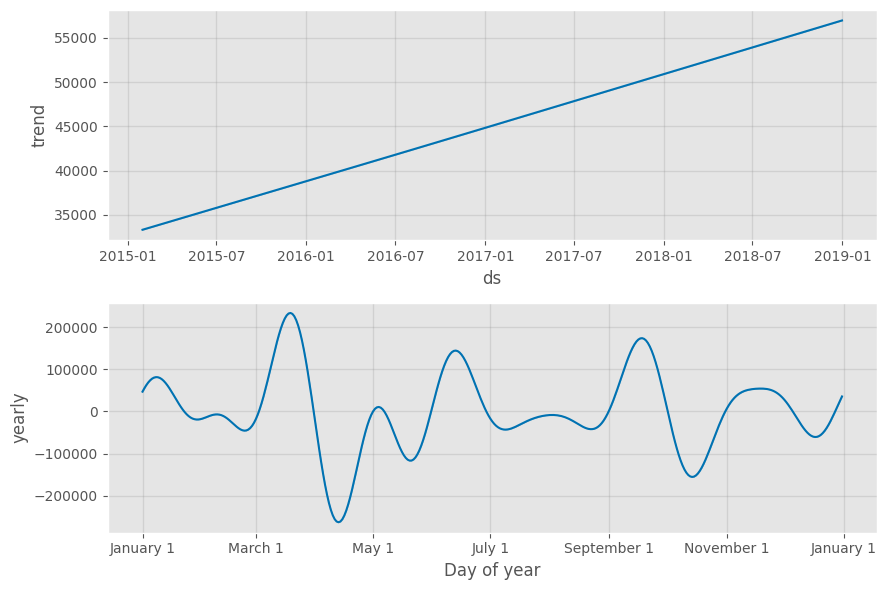

In [66]:
fig2 = model.plot_components(forecast)

plt.show()

In [67]:
pred = forecast.tail(3)["yhat"].values

actual = test["y"].values

In [68]:
prophet_mae = mean_absolute_error(actual,pred)

print("MAE :",prophet_mae)

MAE : 20250.794427610937


In [69]:
prophet_rmse = np.sqrt(mean_squared_error(actual,pred))

print("RMSE :",prophet_rmse)

RMSE : 22318.41136551923


In [70]:
prophet_mape = np.mean(np.abs((actual-pred)/actual))*100

print("MAPE :",prophet_mape)

MAPE : 21.864628287701436


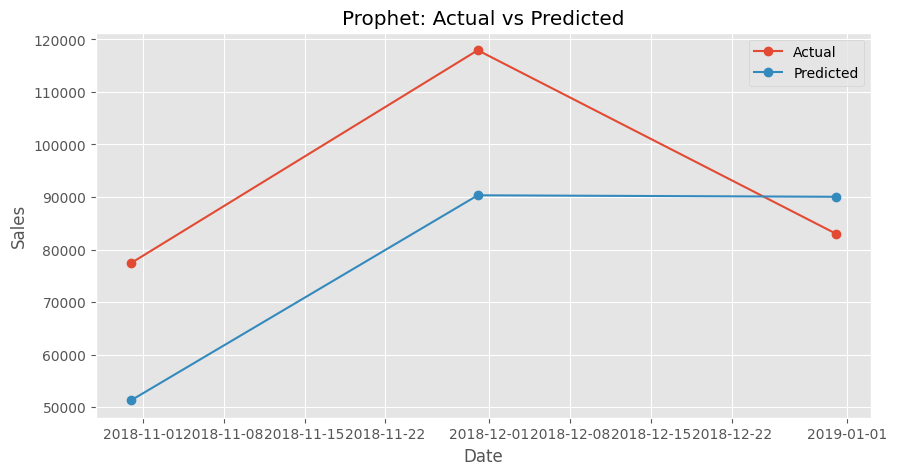

In [71]:
plt.figure(figsize=(10,5))

plt.plot(test["ds"],actual,
         marker="o",
         label="Actual")

plt.plot(test["ds"],pred,
         marker="o",
         label="Predicted")

plt.title("Prophet: Actual vs Predicted")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

In [72]:
final_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

final_prophet.fit(prophet_data)

In [73]:
future = final_prophet.make_future_dataframe(periods=3,freq="M")
future_forecast = final_prophet.predict(future)

/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


In [74]:
future_forecast[["ds","yhat","yhat_lower","yhat_upper"]].tail(3)
prophet_future = future_forecast[["ds","yhat"]].tail(3)

print(prophet_future)

           ds          yhat
48 2019-01-31  42990.532205
49 2019-02-28  31248.159925
50 2019-03-31  81267.007775


The Prophet model captures the long-term sales trend and yearly seasonal pattern in the data. The trend plot shows whether sales are increasing or decreasing over time. The yearly seasonality plot highlights recurring months with higher or lower sales. Since the dataset is aggregated monthly, weekly seasonality is not available. The model generates forecasts along with confidence intervals, which help estimate the uncertainty in future sales.

XGBoost for Time Series

In [75]:
pip install xgboost

In [76]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [77]:
xgb_data = monthly_sales.reset_index(drop=True)

xgb_data.columns = ["Date", "Sales"]

xgb_data.head()

,Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [78]:
xgb_data["Lag_1"] = xgb_data["Sales"].shift(1)

xgb_data["Lag_2"] = xgb_data["Sales"].shift(2)

xgb_data["Lag_3"] = xgb_data["Sales"].shift(3)

In [79]:
xgb_data["Rolling_Mean_3"] = xgb_data["Sales"].rolling(3).mean()

In [80]:
xgb_data["Month"] = xgb_data["Date"].dt.month

xgb_data["Quarter"] = xgb_data["Date"].dt.quarter

In [81]:
def get_season(month):
    if month in [12,1,2]:
        return 1      # Winter
    elif month in [3,4,5]:
        return 2      # Spring
    elif month in [6,7,8]:
        return 3      # Summer
    else:
        return 4      # Autumn

xgb_data["Season"] = xgb_data["Month"].apply(get_season)

In [82]:
xgb_data = xgb_data.dropna()

xgb_data.head()

features = [
    "Lag_1",
    "Lag_2",
    "Lag_3",
    "Rolling_Mean_3",
    "Month",
    "Quarter",
    "Season"
]

X = xgb_data[features]

y = xgb_data["Sales"]

In [83]:
X_train = X[:-3]

X_test = X[-3:]

y_train = y[:-3]

y_test = y[-3:]

In [84]:
model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [85]:
pred = model.predict(X_test)

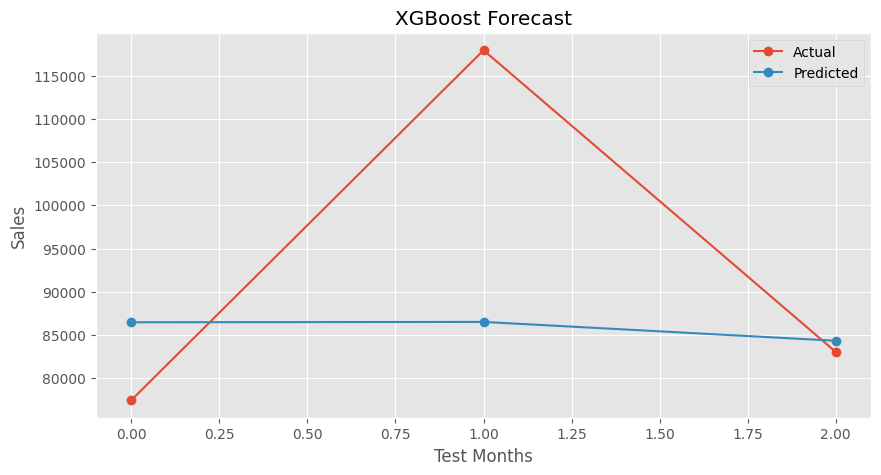

In [86]:
plt.figure(figsize=(10,5))

plt.plot(y_test.values,
         marker="o",
         label="Actual")

plt.plot(pred,
         marker="o",
         label="Predicted")

plt.title("XGBoost Forecast")

plt.xlabel("Test Months")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

In [87]:
xgb_mae = mean_absolute_error(y_test,pred)

print("MAE :",xgb_mae)

MAE : 13915.321041666664


In [88]:
xgb_rmse = np.sqrt(mean_squared_error(y_test,pred))

print("RMSE :",xgb_rmse)

RMSE : 18893.847269098238


In [89]:
xgb_mape = np.mean(np.abs((y_test-pred)/y_test))*100

print("MAPE :",xgb_mape)

MAPE : 13.285400568532047


In [144]:
metrics = pd.DataFrame({
    "Metric": ["MAE", "RMSE"],
    "Value": [mae, rmse]
})

metrics.to_csv("data/model_metrics.csv", index=False)

In [145]:
last.to_frame().T.to_csv(
    "data/last_row.csv",
    index=False
)

In [90]:
comparison = pd.DataFrame({

    "Actual":y_test.values,

    "Predicted":pred

})

print(comparison)

        Actual     Predicted
0   77448.1312  86465.820312
1  117938.1550  86506.773438
2   83030.3888  84327.281250


In [91]:
final_X = xgb_data[features]

final_y = xgb_data["Sales"]

final_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

final_model.fit(final_X, final_y)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [92]:
future_predictions = []

last = xgb_data.iloc[-1].copy()

for i in range(3):

    new_month = (last["Month"] % 12) + 1

    new_quarter = (new_month - 1)//3 + 1

    new_season = get_season(new_month)

    row = [[
        last["Sales"],
        last["Lag_1"],
        last["Lag_2"],
        last["Rolling_Mean_3"],
        new_month,
        new_quarter,
        new_season
    ]]

    forecast = final_model.predict(row)[0]

    future_predictions.append(forecast)

    last["Lag_2"] = last["Lag_1"]
    last["Lag_1"] = last["Sales"]
    last["Sales"] = forecast
    last["Rolling_Mean_3"] = (
        last["Sales"] +
        last["Lag_1"] +
        last["Lag_2"]
    )/3
    last["Month"] = new_month
print(future_predictions)

[np.float32(51862.71), np.float32(31703.658), np.float32(60156.07)]


In [93]:
future_dates = pd.date_range(
    monthly_sales['Order Date'].iloc[-1] + pd.offsets.MonthEnd(),
    periods=3,
    freq="ME"
)

In [94]:
future_table = pd.DataFrame({

    "Date":future_dates,

    "Forecast":future_predictions

})

print(future_table)

        Date      Forecast
0 2019-01-31  51862.710938
1 2019-02-28  31703.658203
2 2019-03-31  60156.070312


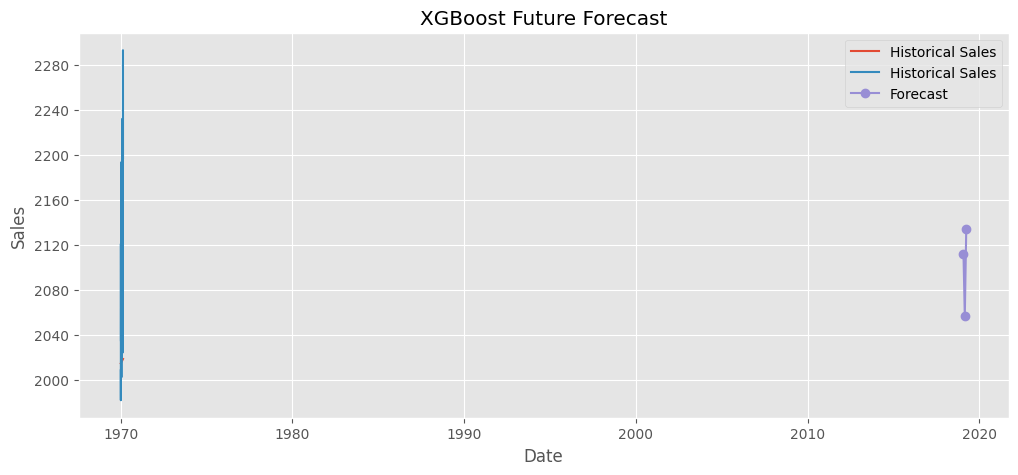

In [95]:
plt.figure(figsize=(12,5))

plt.plot(monthly_sales,
         label="Historical Sales")

plt.plot(future_dates,
         future_predictions,
         marker="o",
         label="Forecast")

plt.title("XGBoost Future Forecast")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

In [96]:
comparison_table = pd.DataFrame({

    "Model":["SARIMA","Prophet","XGBoost"],

    "MAE":[mae, prophet_mae, xgb_mae],

    "RMSE":[rmse, prophet_rmse, xgb_rmse],

    "MAPE":[mape, prophet_mape, xgb_mape],

    "Forecast Month 1":[
        sarima_future.iloc[0],
        prophet_future.iloc[0]["yhat"],
        future_predictions[0]
    ],

    "Forecast Month 2":[
        sarima_future.iloc[1],
        prophet_future.iloc[1]["yhat"],
        future_predictions[1]
    ],

    "Forecast Month 3":[
        sarima_future.iloc[2],
        prophet_future.iloc[2]["yhat"],
        future_predictions[2]
    ]

})
comparison_table=comparison_table.round(2)
print(comparison_table)

     Model       MAE      RMSE   MAPE  Forecast Month 1  Forecast Month 2  \
0   SARIMA  19244.49  19950.07  20.53          60331.79          91458.22   
1  Prophet  20250.79  22318.41  21.86          42990.53          31248.16   
2  XGBoost  13915.32  18893.85  13.29          51862.71          31703.66   

   Forecast Month 3  
0          97167.57  
1          81267.01  
2          60156.07  


In [97]:
import os

forecast_df = pd.DataFrame({
    "Date": future_dates,
    "Forecast": forecast
})

# Create the 'data' directory if it doesn't exist
if not os.path.exists('data'):
    os.makedirs('data')

forecast_df.to_csv("data/forecast.csv", index=False)

print("Forecast saved.")

Forecast saved.


Among the three forecasting models, XGBoost achieved the best performance with the lowest MAE (13,915.32), RMSE (18,893.85), and MAPE (13.29%). This indicates that it produced the most accurate predictions on the test data. Therefore, XGBoost is recommended for production use because it provides more reliable sales forecasts, which can help businesses optimize inventory management and reduce stock shortages or overstocking.The XGBoost model generally predicted sales close to the actual values but underestimated the large sales spike observed in one month. This behavior is expected because the model was trained on a relatively small monthly dataset and tends to smooth extreme values. Despite this limitation, it achieved the lowest MAE, RMSE, and MAPE among the three models, making it the best-performing approach for this project.

Task 4 — Product Category & Region Level Forecasting


In [99]:
from xgboost import XGBRegressor

def get_season(month):
    if month in [12, 1, 2]:
        return 1
    elif month in [3, 4, 5]:
        return 2
    elif month in [6, 7, 8]:
        return 3
    else:
        return 4


def forecast_segment(data):

    monthly = data.resample("M", on="Order Date")["Sales"].sum().reset_index()

    monthly.columns = ["Date", "Sales"]

    monthly["Lag_1"] = monthly["Sales"].shift(1)
    monthly["Lag_2"] = monthly["Sales"].shift(2)
    monthly["Lag_3"] = monthly["Sales"].shift(3)

    monthly["Rolling_Mean_3"] = monthly["Sales"].rolling(3).mean()

    monthly["Month"] = monthly["Date"].dt.month
    monthly["Quarter"] = monthly["Date"].dt.quarter
    monthly["Season"] = monthly["Month"].apply(get_season)

    monthly = monthly.dropna()

    features = [
        "Lag_1",
        "Lag_2",
        "Lag_3",
        "Rolling_Mean_3",
        "Month",
        "Quarter",
        "Season"
    ]

    X = monthly[features]
    y = monthly["Sales"]

    model = XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )

    model.fit(X, y)

    import joblib
    import os

    os.makedirs("models", exist_ok=True)

    joblib.dump(model, "models/xgboost_model.pkl")

    last = monthly.iloc[-1].copy()

    predictions = []

    for i in range(3):

        new_month = (last["Month"] % 12) + 1
        new_quarter = (new_month - 1) // 3 + 1
        new_season = get_season(new_month)

        row = [[
            last["Sales"],
            last["Lag_1"],
            last["Lag_2"],
            last["Rolling_Mean_3"],
            new_month,
            new_quarter,
            new_season
        ]]

        pred = model.predict(row)[0]

        predictions.append(pred)

        last["Lag_2"] = last["Lag_1"]
        last["Lag_1"] = last["Sales"]
        last["Sales"] = pred
        last["Rolling_Mean_3"] = (
            last["Sales"] +
            last["Lag_1"] +
            last["Lag_2"]
        ) / 3
        last["Month"] = new_month

    return predictions

In [100]:
furniture = sales[sales["Category"] == "Furniture"]

furniture_forecast = forecast_segment(furniture)

print(furniture_forecast)

[np.float32(9716.003), np.float32(6214.6865), np.float32(16723.81)]


/tmp/ipykernel_578/971414017.py:16: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = data.resample("M", on="Order Date")["Sales"].sum().reset_index()


In [101]:
technology = sales[sales["Category"] == "Technology"]

technology_forecast = forecast_segment(technology)

print(technology_forecast)

[np.float32(20370.967), np.float32(24370.316), np.float32(30328.62)]


/tmp/ipykernel_578/971414017.py:16: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = data.resample("M", on="Order Date")["Sales"].sum().reset_index()


In [102]:
office = sales[sales["Category"] == "Office Supplies"]

office_forecast = forecast_segment(office)

print(office_forecast)

[np.float32(25796.031), np.float32(25957.26), np.float32(29761.83)]


/tmp/ipykernel_578/971414017.py:16: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = data.resample("M", on="Order Date")["Sales"].sum().reset_index()


In [103]:
west = sales[sales["Region"] == "West"]

west_forecast = forecast_segment(west)

print(west_forecast)

[np.float32(11175.512), np.float32(15125.339), np.float32(21355.615)]


/tmp/ipykernel_578/971414017.py:16: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = data.resample("M", on="Order Date")["Sales"].sum().reset_index()


In [104]:
east = sales[sales["Region"] == "East"]

east_forecast = forecast_segment(east)

print(east_forecast)

/tmp/ipykernel_578/971414017.py:16: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = data.resample("M", on="Order Date")["Sales"].sum().reset_index()


[np.float32(25088.459), np.float32(25353.447), np.float32(27580.826)]


In [105]:
future_dates = pd.date_range(
    monthly_sales['Order Date'].iloc[-1] + pd.offsets.MonthEnd(),
    periods=3,
    freq="ME"
)

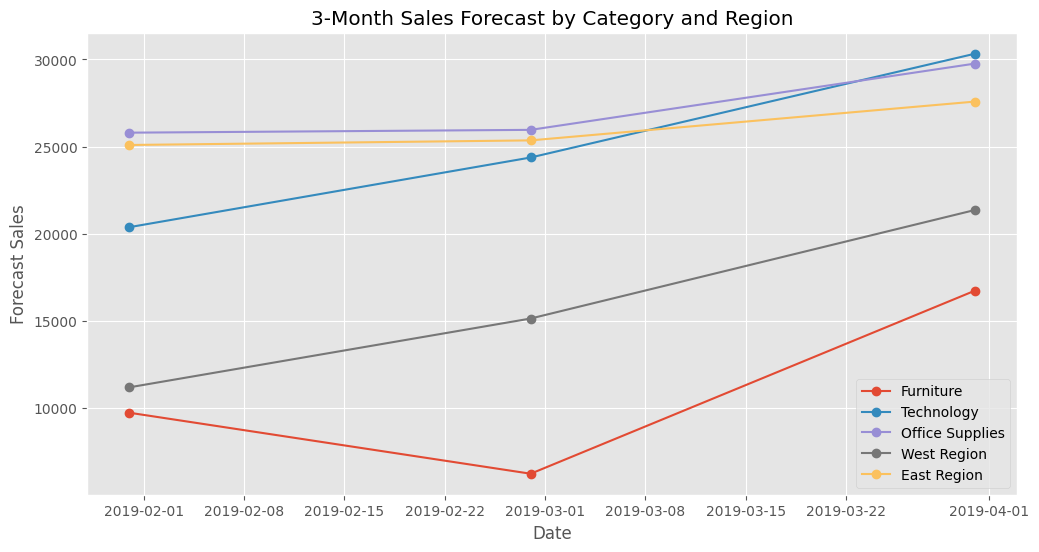

In [106]:
plt.figure(figsize=(12,6))

plt.plot(future_dates,
         furniture_forecast,
         marker="o",
         label="Furniture")

plt.plot(future_dates,
         technology_forecast,
         marker="o",
         label="Technology")

plt.plot(future_dates,
         office_forecast,
         marker="o",
         label="Office Supplies")

plt.plot(future_dates,
         west_forecast,
         marker="o",
         label="West Region")

plt.plot(future_dates,
         east_forecast,
         marker="o",
         label="East Region")

plt.title("3-Month Sales Forecast by Category and Region")

plt.xlabel("Date")

plt.ylabel("Forecast Sales")

plt.legend()

plt.grid(True)

plt.show()

In [107]:
forecast_table = pd.DataFrame({

    "Month": future_dates,

    "Furniture": furniture_forecast,

    "Technology": technology_forecast,

    "Office Supplies": office_forecast,

    "West Region": west_forecast,

    "East Region": east_forecast

})

forecast_table = forecast_table.round(2)

print(forecast_table)

       Month     Furniture    Technology  Office Supplies   West Region  \
0 2019-01-31   9716.000000  20370.970703     25796.029297  11175.509766   
1 2019-02-28   6214.689941  24370.320312     25957.259766  15125.339844   
2 2019-03-31  16723.810547  30328.619141     29761.830078  21355.619141   

    East Region  
0  25088.460938  
1  25353.449219  
2  27580.820312  


In [108]:
growth = {

    "Furniture": furniture_forecast[-1] - furniture_forecast[0],

    "Technology": technology_forecast[-1] - technology_forecast[0],

    "Office Supplies": office_forecast[-1] - office_forecast[0],

    "West Region": west_forecast[-1] - west_forecast[0],

    "East Region": east_forecast[-1] - east_forecast[0]

}

growth

{'Furniture': np.float32(7007.8076),
 'Technology': np.float32(9957.652),
 'Office Supplies': np.float32(3965.7988),
 'West Region': np.float32(10180.104),
 'East Region': np.float32(2492.3672)}

In [109]:
best = max(growth, key=growth.get)

print("Highest Growth Segment:", best)

Highest Growth Segment: West Region


Based on the XGBoost forecasting model, West Region is expected to show the strongest growth over the next three months. This segment has the highest increase in forecasted sales among the selected product categories and regions. The forecast suggests that the business should prioritize inventory planning and stock availability for this segment to meet the expected increase in demand.

Task 5 — Anomaly Detection in Sales Data

In [110]:
from sklearn.ensemble import IsolationForest
from scipy.stats import zscore

In [111]:
weekly_sales = sales.resample("W", on="Order Date")["Sales"].sum().reset_index()

weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


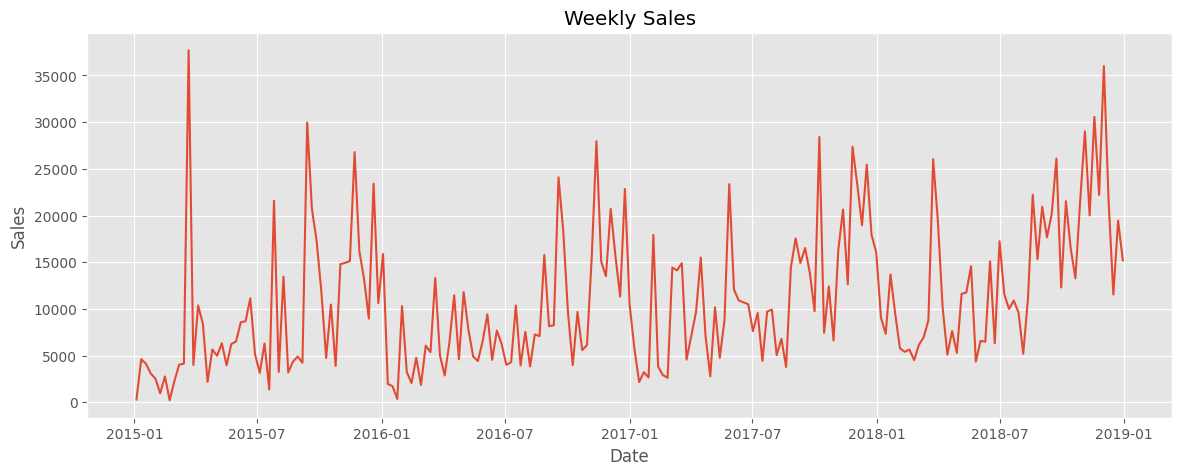

In [112]:
plt.figure(figsize=(14,5))

plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"]
)

plt.title("Weekly Sales")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.grid(True)

plt.show()

Isolation Forest

In [113]:
iso = IsolationForest(
    contamination=0.05,
    random_state=42
)

weekly_sales["Anomaly"] = iso.fit_predict(
    weekly_sales[["Sales"]]
)

In [114]:
print(weekly_sales["Anomaly"].value_counts())

Anomaly
 1    198
-1     11
Name: count, dtype: int64


In [115]:
anomalies = weekly_sales[
    weekly_sales["Anomaly"] == -1
]

print(anomalies)

    Order Date      Sales  Anomaly
0   2015-01-04    304.508       -1
5   2015-02-08    968.534       -1
7   2015-02-22    224.912       -1
11  2015-03-22  37703.665       -1
28  2015-07-19   1387.686       -1
36  2015-09-13  29959.137       -1
55  2016-01-24    358.522       -1
154 2017-12-17  25449.800       -1
200 2018-11-04  29017.467       -1
202 2018-11-18  30572.447       -1
204 2018-12-02  35998.900       -1


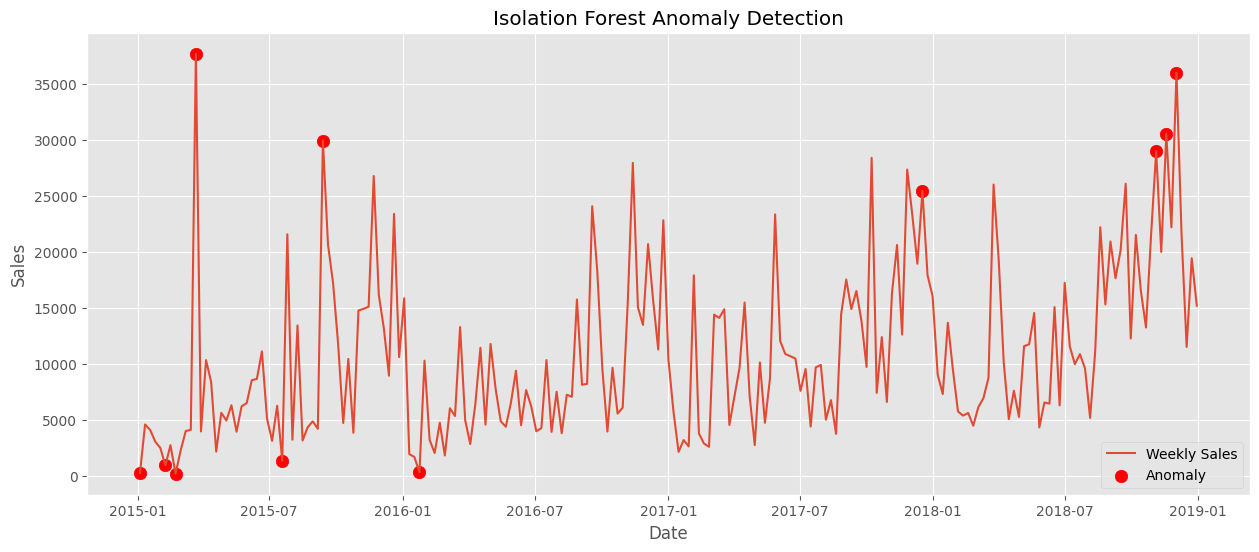

In [116]:
plt.figure(figsize=(15,6))

plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    label="Weekly Sales"
)

plt.scatter(
    anomalies["Order Date"],
    anomalies["Sales"],
    color="red",
    s=80,
    label="Anomaly"
)

plt.title("Isolation Forest Anomaly Detection")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

In [117]:
anomalies[["Order Date","Sales"]]

,Order Date,Sales
0,2015-01-04,304.508
5,2015-02-08,968.534
7,2015-02-22,224.912
11,2015-03-22,37703.665
28,2015-07-19,1387.686
36,2015-09-13,29959.137
55,2016-01-24,358.522
154,2017-12-17,25449.800
200,2018-11-04,29017.467
202,2018-11-18,30572.447


In [118]:
anomaly_df = weekly_sales[weekly_sales["Anomaly"] == -1][["Order Date","Sales"]]

anomaly_df.to_csv("data/anomalies.csv", index=False)

print("Anomalies saved.")

Anomalies saved.


Isolation Forest identified several weeks with unusually high or low sales compared to the normal sales pattern. These weeks may represent promotional events, festive seasons, unexpected demand increases, or operational issues.

Z-Score Detection

In [119]:
weekly_sales["Rolling Mean"] = (
    weekly_sales["Sales"]
    .rolling(4)
    .mean()
)

In [120]:
weekly_sales["Rolling Std"] = (
    weekly_sales["Sales"]
    .rolling(4)
    .std()
)

In [121]:
weekly_sales["Z Score"] = (
    weekly_sales["Sales"] -
    weekly_sales["Rolling Mean"]
) / weekly_sales["Rolling Std"]

In [122]:
weekly_sales["Z_Anomaly"] = (
    weekly_sales["Z Score"].abs() > 2
)

z_anomalies = weekly_sales[
    weekly_sales["Z_Anomaly"]
]

print(z_anomalies)

Empty DataFrame
Columns: [Order Date, Sales, Anomaly, Rolling Mean, Rolling Std, Z Score, Z_Anomaly]
Index: []


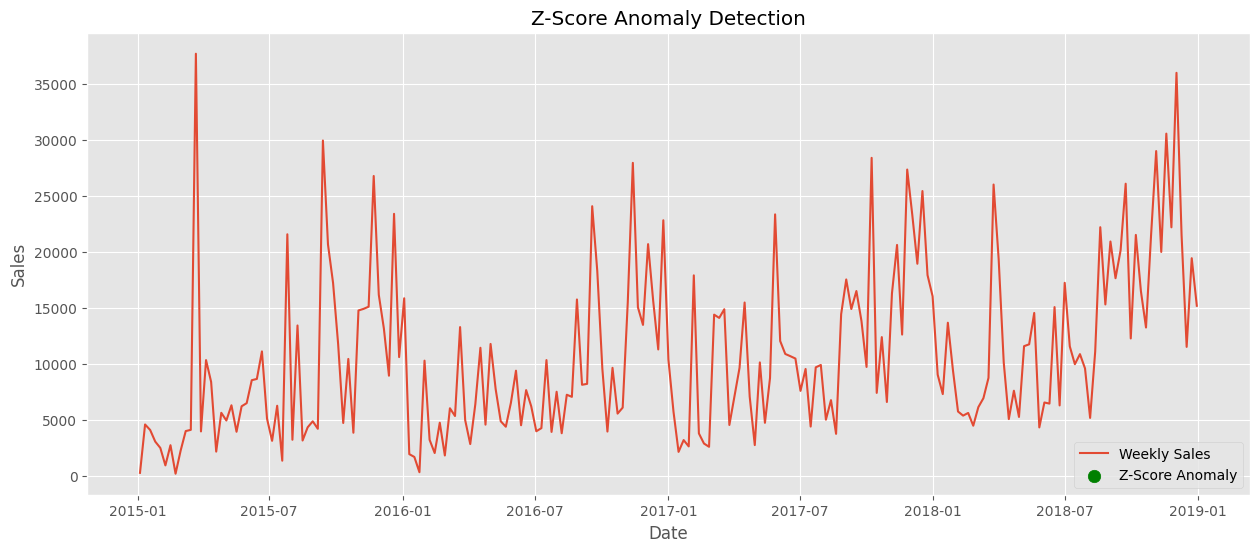

In [123]:
plt.figure(figsize=(15,6))

plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    label="Weekly Sales"
)

plt.scatter(
    z_anomalies["Order Date"],
    z_anomalies["Sales"],
    color="green",
    s=80,
    label="Z-Score Anomaly"
)

plt.title("Z-Score Anomaly Detection")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

In [124]:
iso_dates = set(anomalies["Order Date"])

z_dates = set(z_anomalies["Order Date"])

common = iso_dates.intersection(z_dates)


print("Isolation Forest :",len(iso_dates))

print("Z Score :",len(z_dates))

print("Common :",len(common))

Isolation Forest : 11
Z Score : 0
Common : 0


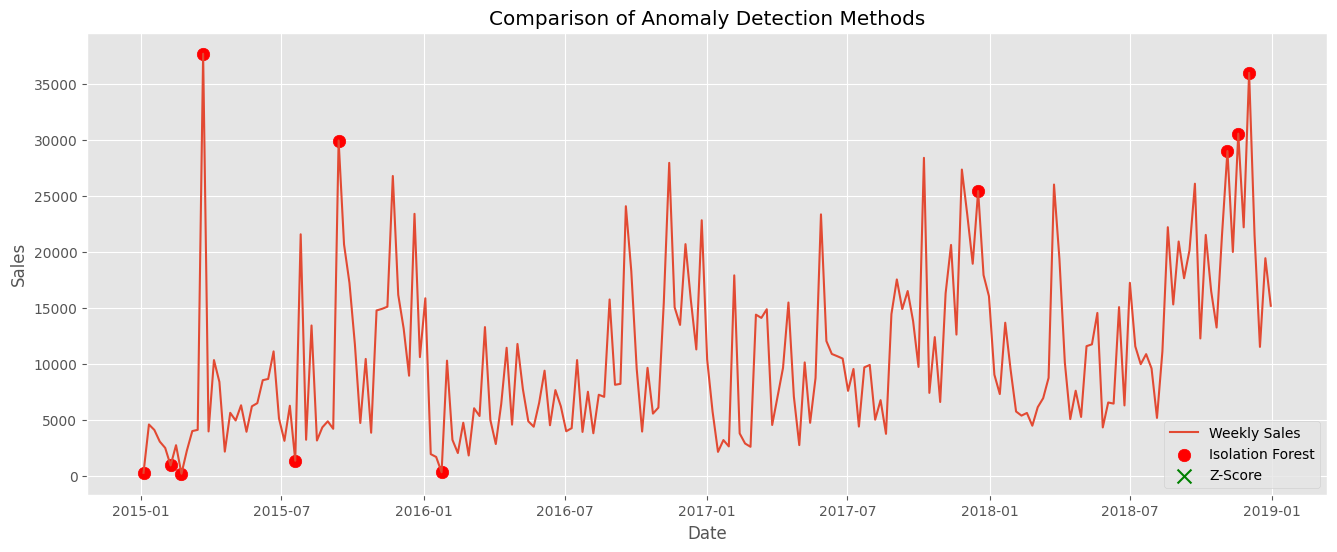

In [125]:
plt.figure(figsize=(16,6))

plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    label="Weekly Sales"
)

plt.scatter(
    anomalies["Order Date"],
    anomalies["Sales"],
    color="red",
    s=80,
    label="Isolation Forest"
)

plt.scatter(
    z_anomalies["Order Date"],
    z_anomalies["Sales"],
    color="green",
    marker="x",
    s=100,
    label="Z-Score"
)

plt.title("Comparison of Anomaly Detection Methods")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

In [126]:
print(anomalies[["Order Date","Sales"]])
print(z_anomalies[["Order Date","Sales"]])

    Order Date      Sales
0   2015-01-04    304.508
5   2015-02-08    968.534
7   2015-02-22    224.912
11  2015-03-22  37703.665
28  2015-07-19   1387.686
36  2015-09-13  29959.137
55  2016-01-24    358.522
154 2017-12-17  25449.800
200 2018-11-04  29017.467
202 2018-11-18  30572.447
204 2018-12-02  35998.900
Empty DataFrame
Columns: [Order Date, Sales]
Index: []


The Z-Score method detects observations that are more than two standard deviations away from the rolling mean. It focuses on statistical deviations within a local window.

Task 6 — Product Demand Segmentation using Clustering

In [127]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [128]:
monthly = sales.groupby(
    ["Sub-Category", pd.Grouper(key="Order Date", freq="M")]
)["Sales"].sum().reset_index()

monthly.head()

/tmp/ipykernel_578/3462652998.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ["Sub-Category", pd.Grouper(key="Order Date", freq="M")]


,Sub-Category,Order Date,Sales
0,Accessories,2015-01-31,827.890
1,Accessories,2015-02-28,1120.990
2,Accessories,2015-03-31,957.734
3,Accessories,2015-04-30,2323.700
4,Accessories,2015-05-31,695.490


In [129]:
total_sales = monthly.groupby("Sub-Category")["Sales"].sum()
volatility = monthly.groupby("Sub-Category")["Sales"].std()
avg_order = sales.groupby("Sub-Category")["Sales"].mean()

In [130]:
yearly = sales.groupby(
    ["Sub-Category", "Year"]
)["Sales"].sum().reset_index()

pivot = yearly.pivot(
    index="Sub-Category",
    columns="Year",
    values="Sales"
)

pivot = pivot.fillna(0)

In [131]:
growth = (
    (pivot.iloc[:, -1] - pivot.iloc[:, 0])
    / (pivot.iloc[:, 0] + 1)
) * 100

In [132]:
cluster_data = pd.DataFrame({

    "Total Sales": total_sales,

    "Growth Rate": growth,

    "Volatility": volatility,

    "Average Order Value": avg_order

})

cluster_data = cluster_data.fillna(0)

cluster_data

,Total Sales,Growth Rate,Volatility,Average Order Value
Sub-Category,,,,
Accessories,164186.7000,145.049857,2579.994809,217.178175
Appliances,104618.4030,165.232014,1821.621539,227.926804
Art,26705.4100,49.641114,330.488343,34.019631
Binders,200028.7850,65.777118,3848.223648,134.067550
Bookcases,113813.1987,49.844110,2220.405080,503.598224
Chairs,322822.7310,20.954405,4407.232960,531.833165
Copiers,146248.0940,479.685298,5500.774391,2215.880212
Envelopes,16128.0460,-12.118193,228.218688,65.032444
Fasteners,3001.9600,30.421946,48.742229,14.027850


In [133]:
scaler = StandardScaler()

scaled = scaler.fit_transform(cluster_data)

In [134]:
wcss = []

for i in range(1, 11):

    model = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    model.fit(scaled)

    wcss.append(model.inertia_)

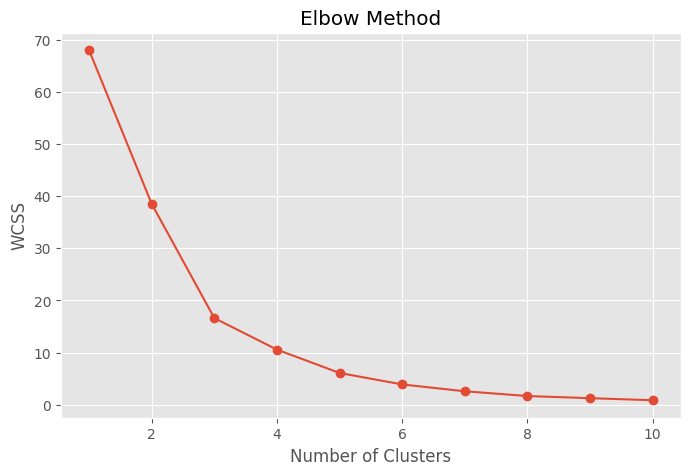

In [135]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker="o")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.grid(True)

plt.show()

In [136]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

cluster_data["Cluster"] = kmeans.fit_predict(scaled)
cluster_data

,Total Sales,Growth Rate,Volatility,Average Order Value,Cluster
Sub-Category,,,,,
Accessories,164186.7000,145.049857,2579.994809,217.178175,0
Appliances,104618.4030,165.232014,1821.621539,227.926804,2
Art,26705.4100,49.641114,330.488343,34.019631,2
Binders,200028.7850,65.777118,3848.223648,134.067550,0
Bookcases,113813.1987,49.844110,2220.405080,503.598224,2
Chairs,322822.7310,20.954405,4407.232960,531.833165,0
Copiers,146248.0940,479.685298,5500.774391,2215.880212,1
Envelopes,16128.0460,-12.118193,228.218688,65.032444,2
Fasteners,3001.9600,30.421946,48.742229,14.027850,2


In [137]:
pca = PCA(n_components=2)

points = pca.fit_transform(scaled)

plot_data = pd.DataFrame({

    "PC1": points[:,0],

    "PC2": points[:,1],

    "Cluster": cluster_data["Cluster"],

    "Sub-Category": cluster_data.index

})

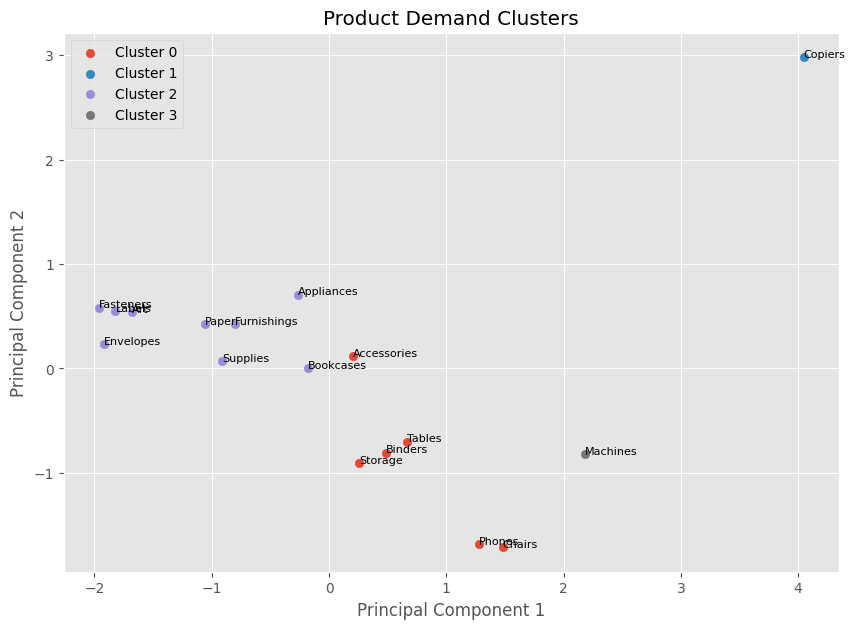

In [138]:
plt.figure(figsize=(10,7))

for cluster in sorted(plot_data["Cluster"].unique()):

    temp = plot_data[
        plot_data["Cluster"] == cluster
    ]

    plt.scatter(
        temp["PC1"],
        temp["PC2"],
        label=f"Cluster {cluster}"
    )

for i in range(len(plot_data)):

    plt.text(
        plot_data.iloc[i]["PC1"],
        plot_data.iloc[i]["PC2"],
        plot_data.iloc[i]["Sub-Category"],
        fontsize=8
    )

plt.title("Product Demand Clusters")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.legend()

plt.grid(True)

plt.show()

In [139]:
summary = cluster_data.groupby("Cluster").mean()

print(summary)

           Total Sales  Growth Rate   Volatility  Average Order Value
Cluster                                                              
0        239495.780667    56.463525  3489.056075           361.131228
1        146248.094000   479.685298  5500.774391          2215.880212
2         54341.708189    58.785505  1031.431565           142.746758
3        189238.631000   -29.792640  5603.554747          1645.553313


In [147]:
cluster_df = cluster_data.reset_index()

cluster_df = cluster_df[
    [
        "Sub-Category",
        "Total Sales",
        "Growth Rate",
        "Volatility",
        "Average Order Value",
        "Cluster"
    ]
].copy()

cluster_df.to_csv("clusters.csv", index=False)

Product Segments

K-Means clustering grouped the product sub-categories into four demand segments based on total sales, growth rate, sales volatility, and average order value. Products within the same cluster show similar demand patterns.

Stocking Strategy

You can use recommendations like these:

High Volume, Stable Demand: Maintain higher inventory levels to avoid stock-outs.
Low Volume, High Volatility: Keep limited safety stock and monitor demand frequently.
Growing Demand: Increase inventory gradually and review forecasts regularly.
Declining Demand: Reduce stock levels and avoid over-ordering to minimize excess inventory.

In [141]:
sales.to_csv("data/sales_cleaned.csv", index=False)

In [142]:
import joblib
import os

# Create models folder
os.makedirs("models", exist_ok=True)

# Save trained model
joblib.dump(final_model, "models/xgboost_model.pkl")

print("Model saved successfully!")

Model saved successfully!
